# 07｜集成學習與隨機森林

對應 `slides/07_集成學習與隨機森林.md`。本檔由 `12_集成學習與隨機森林.ipynb` 改名，程式與已執行輸出保留。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 硬投票 vs 軟投票，以及投影片手算

硬投票數類別票數；軟投票平均機率再取 argmax。對應投影片活動：三個模型正類機率 `[0.51, 0.51, 0.01]`。

In [2]:
probs = np.array([0.51, 0.51, 0.01])
hard = int(np.sum(probs >= 0.5) > len(probs) / 2)      # 兩票正類 -> 1
soft = int(probs.mean() >= 0.5)                        # 平均約 0.343 -> 0
assert hard == 1 and soft == 0 and np.isclose(probs.mean(), 0.343333, atol=1e-5)
print('hard vote:', hard, ' soft vote:', soft, ' mean prob:', round(probs.mean(), 4))

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
Xm, ym = make_moons(n_samples=500, noise=.3, random_state=SEED)
Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=.3, random_state=SEED)
base = [('lr', make_pipeline(StandardScaler(), LogisticRegression())),
        ('svc', make_pipeline(StandardScaler(), SVC(probability=True, random_state=SEED))),
        ('tree', DecisionTreeClassifier(max_depth=4, random_state=SEED))]
rows = []
for voting in ['hard', 'soft']:
    vc = VotingClassifier(base, voting=voting).fit(Xtr, ytr)
    rows.append({'voting': voting, 'test_accuracy': vc.score(Xte, yte)})
for name, est in base:
    est.fit(Xtr, ytr); rows.append({'voting': name, 'test_accuracy': est.score(Xte, yte)})
pd.DataFrame(rows).set_index('voting')

hard vote: 1  soft vote: 0  mean prob: 0.3433


,test_accuracy
voting,
hard,0.886667
soft,0.893333
lr,0.860000
svc,0.906667
tree,0.880000


## 2. Bagging：不同抽樣資料訓練同一種模型

每個估計器看 bootstrap 抽樣的資料，邊界通常比單棵樹平滑（教材圖 6-5）。袋外（OOB）樣本可做免費的驗證估計。

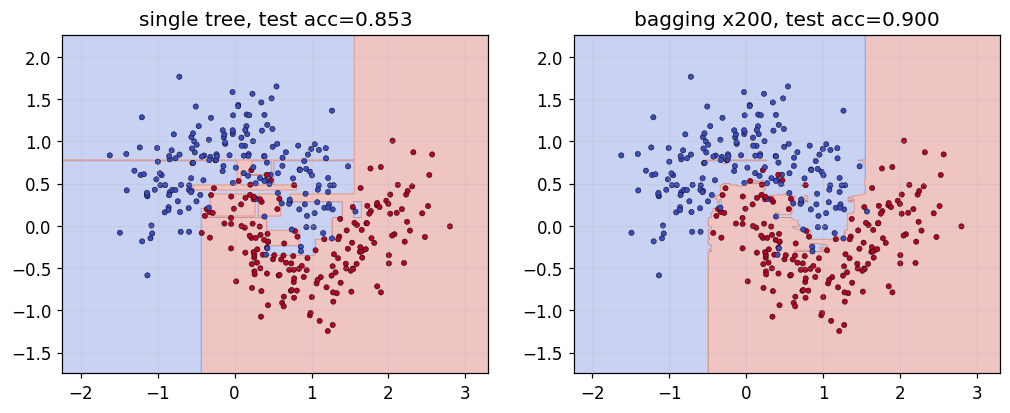

bagging OOB score: 0.891  | test score: 0.9


In [3]:
from sklearn.ensemble import BaggingClassifier
xx, yy = np.meshgrid(np.linspace(Xm[:, 0].min() - .5, Xm[:, 0].max() + .5, 300),
                     np.linspace(Xm[:, 1].min() - .5, Xm[:, 1].max() + .5, 300))
single = DecisionTreeClassifier(random_state=SEED).fit(Xtr, ytr)
bag = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=200,
                        oob_score=True, random_state=SEED, n_jobs=2).fit(Xtr, ytr)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m, name in [(axes[0], single, 'single tree'), (axes[1], bag, 'bagging x200')]:
    zz = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=.3, cmap='coolwarm')
    ax.scatter(Xtr[:, 0], Xtr[:, 1], c=ytr, cmap='coolwarm', s=12, edgecolor='k', linewidth=.3)
    ax.set_title(f'{name}, test acc={m.score(Xte, yte):.3f}')
savefig('12_bagging_boundary')
print('bagging OOB score:', round(bag.oob_score_, 3), ' | test score:', round(bag.score(Xte, yte), 3))

## 3. 隨機森林、Extra Trees 與特徵重要度

森林在每個分割點只考慮隨機特徵子集。用本機 MNIST 快取的子樣本訓練，把不純度重要度 reshape 回 28×28（教材圖 6-6）。重要度可偏好高基數特徵，不能解讀成因果。

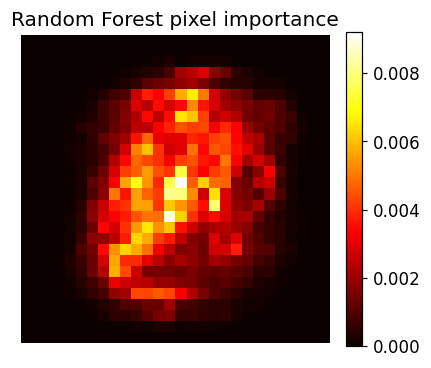

held-out accuracy  RandomForest: 0.938  ExtraTrees: 0.949


In [4]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
with np.load(data_path('mnist_784_v1.npz')) as arch:
    images, labels = arch['X'], arch['y']
idx = np.random.default_rng(SEED).choice(60000, 8000, replace=False)
Xd = (images[idx].astype(np.float32) / 255); yd = labels[idx]
Xdtr, Xdte, ydtr, ydte = train_test_split(Xd, yd, test_size=2000, stratify=yd, random_state=SEED)
rf = RandomForestClassifier(n_estimators=120, max_features='sqrt', n_jobs=2, random_state=SEED).fit(Xdtr, ydtr)
et = ExtraTreesClassifier(n_estimators=120, max_features='sqrt', n_jobs=2, random_state=SEED).fit(Xdtr, ydtr)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(rf.feature_importances_.reshape(28, 28), cmap='hot')
ax.set_title('Random Forest pixel importance'); ax.axis('off'); fig.colorbar(im, ax=ax, fraction=.046)
savefig('12_forest_importance')
imp = rf.feature_importances_.reshape(28, 28)
assert imp[10:18, 10:18].mean() > imp[:4, :4].mean()          # 中央像素較常參與有效分割
print('held-out accuracy  RandomForest:', round(rf.score(Xdte, ydte), 3),
      ' ExtraTrees:', round(et.score(Xdte, ydte), 3))

## 4. 手算 AdaBoost 第一輪

對應投影片活動。四筆資料初始權重 $1/4$，第一個模型只錯一筆，$\eta=1$。$r$ 是加權錯誤率、$\alpha=\eta\log\frac{1-r}{r}$。

In [5]:
w = np.full(4, 1 / 4)
wrong = np.array([True, False, False, False])
r = w[wrong].sum()
alpha = 1.0 * np.log((1 - r) / r)
w_new = w * np.exp(alpha * wrong)             # 只放大錯分樣本
w_norm = w_new / w_new.sum()
assert np.isclose(r, .25) and np.isclose(alpha, np.log(3))
assert np.isclose(w_norm[wrong][0], .5) and np.allclose(w_norm[~wrong], 1 / 6)
pd.Series({'r': r, 'alpha': alpha, 'weight_wrong_after': w_norm[wrong][0],
           'weight_correct_after': w_norm[~wrong][0]})

r                       0.250000
alpha                   1.098612
weight_wrong_after      0.500000
weight_correct_after    0.166667
dtype: float64

## 5. Gradient Boosting：平方損失時逐棵學殘差

每棵新樹擬合目前的殘差，預測是所有樹的加總乘以學習率（教材圖 6-9）。學習率小通常需要更多棵樹（圖 6-10）。

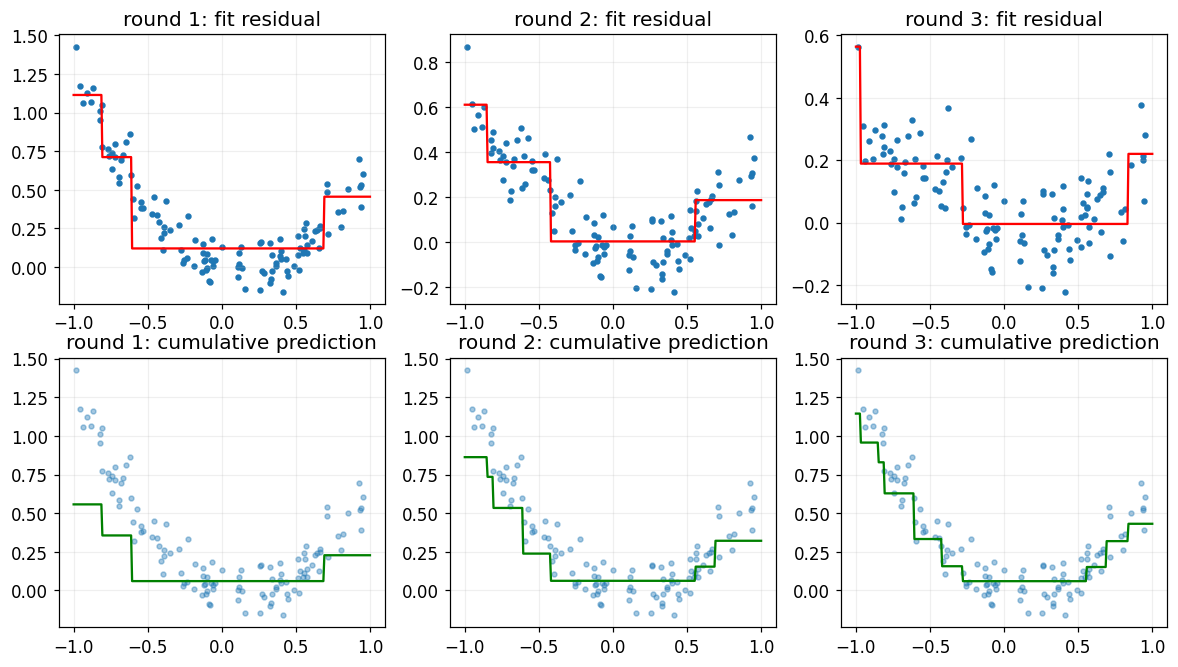

,learning_rate,n_estimators,train_RMSE
0,1.0,5,0.085391
1,1.0,30,0.037270
2,1.0,120,0.000708
3,0.1,5,0.225779
4,0.1,30,0.085938
5,0.1,120,0.061937


In [6]:
from sklearn.tree import DecisionTreeRegressor
rng = np.random.default_rng(SEED)
xg = np.sort(rng.uniform(-1, 1, 120))[:, None]
yg = xg[:, 0] ** 2 - 0.3 * xg[:, 0] + rng.normal(0, .1, 120)
g = np.linspace(-1, 1, 300)[:, None]
residual = yg.copy(); cumulative = np.zeros(len(g)); lr = 0.5
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for k in range(3):
    stump = DecisionTreeRegressor(max_depth=2, random_state=SEED).fit(xg, residual)
    axes[0, k].scatter(xg, residual, s=10); axes[0, k].plot(g, stump.predict(g), 'r-')
    axes[0, k].set_title(f'round {k + 1}: fit residual')
    cumulative = cumulative + lr * stump.predict(g)
    axes[1, k].scatter(xg, yg, s=10, alpha=.4); axes[1, k].plot(g, cumulative, 'g-')
    axes[1, k].set_title(f'round {k + 1}: cumulative prediction')
    residual = residual - lr * stump.predict(xg)
savefig('12_gradient_boosting_stages')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error
lr_rows = []
for lr_ in [1.0, 0.1]:
    for n in [5, 30, 120]:
        gb = GradientBoostingRegressor(learning_rate=lr_, n_estimators=n, max_depth=2, random_state=SEED).fit(xg, yg)
        lr_rows.append({'learning_rate': lr_, 'n_estimators': n, 'train_RMSE': root_mean_squared_error(yg, gb.predict(xg))})
lr_table = pd.DataFrame(lr_rows)
assert lr_table.query('learning_rate == 0.1')['train_RMSE'].iloc[0] > lr_table.query('learning_rate == 1.0')['train_RMSE'].iloc[0]
lr_table

## 6. Stacking 與洩漏：第二層必須用折外預測

第二層（blender）的訓練特徵要用樣本外方式產生（教材圖 6-12）。直接用第一層對訓練資料的預測，會給高容量基模型「記住答案」的機會。

In [7]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_predict
estimators = [('tree', DecisionTreeClassifier(max_depth=4, random_state=SEED)),
              ('svc', make_pipeline(StandardScaler(), SVC(probability=True, random_state=SEED)))]
stack = StackingClassifier(estimators, final_estimator=LogisticRegression(), cv=5).fit(Xtr, ytr)

# 洩漏對照：用「記住答案」的滿樹對訓練資料的預測當第二層特徵
leaky_base = DecisionTreeClassifier(random_state=SEED).fit(Xtr, ytr)
leaky_feat_train = leaky_base.predict_proba(Xtr)[:, 1:2]           # in-sample -> 幾乎完美
proper_feat_train = cross_val_predict(DecisionTreeClassifier(random_state=SEED), Xtr, ytr,
                                      cv=5, method='predict_proba')[:, 1:2]
blender_leaky = LogisticRegression().fit(leaky_feat_train, ytr)
blender_proper = LogisticRegression().fit(proper_feat_train, ytr)
leaky_cv = blender_leaky.score(leaky_feat_train, ytr)
proper_cv = cross_val_score(LogisticRegression(), proper_feat_train, ytr, cv=5).mean()
assert leaky_cv > proper_cv
print('stacking test accuracy:', round(stack.score(Xte, yte), 3))
print('blender train acc with in-sample feature (leaky):', round(leaky_cv, 3),
      ' | with out-of-fold feature:', round(proper_cv, 3))

stacking test accuracy: 0.92
blender train acc with in-sample feature (leaky): 1.0  | with out-of-fold feature: 0.869


## 7. 同一切分：單樹、森林、提升樹

固定 moons 訓練資料與 5 折 CV，比較三種模型的 CV 準確率、標準差與訓練時間。

In [8]:
import time
from sklearn.ensemble import HistGradientBoostingClassifier
rows = []
for name, est in {'shallow_tree': DecisionTreeClassifier(max_depth=3, random_state=SEED),
                  'random_forest_200': RandomForestClassifier(n_estimators=200, n_jobs=2, random_state=SEED),
                  'hist_grad_boosting': HistGradientBoostingClassifier(max_iter=200, random_state=SEED)}.items():
    t0 = time.perf_counter()
    cv = cross_val_score(est, Xtr, ytr, cv=5)
    fit_s = time.perf_counter() - t0
    est.fit(Xtr, ytr)
    rows.append({'model': name, 'CV_accuracy': cv.mean(), 'CV_sd': cv.std(ddof=1),
                 'test_accuracy': est.score(Xte, yte), 'cv_seconds': round(fit_s, 3)})
compare = pd.DataFrame(rows).set_index('model')
report('ensembles', {'vote_check': {'hard': 1, 'soft': 0}, 'bagging_oob': float(bag.oob_score_),
       'adaboost_round1': {'r': float(r), 'alpha': float(alpha)},
       'gb_learning_rate_trees': lr_table.to_dict('records'),
       'stacking_leaky_vs_proper': [float(leaky_cv), float(proper_cv)],
       'model_comparison': compare.to_dict()})
compare

,CV_accuracy,CV_sd,test_accuracy,cv_seconds
model,,,,
shallow_tree,0.874286,0.027479,0.886667,0.004
random_forest_200,0.900000,0.020203,0.900000,0.541
hist_grad_boosting,0.900000,0.026726,0.893333,4.248


## 練習與參考答案

- 硬投票與軟投票何時不同？**當被少數模型的過度自信機率拉動平均時；需檢查校準。**
- 「重複同一模型、同一種子 100 次」能形成有效多樣性嗎？**不能，預測完全相同。**
- AdaBoost 一直放大同一個錯誤標籤會怎樣？**標籤雜訊被持續放大，可能過擬合雜訊。**
- stacking 訓練特徵看起來完美，代表模型好嗎？**否，很可能是用了記住答案的 in-sample 預測。**